# Over-optimization curve (KL vs reward)
This notebook reads DRRO/GRPO log CSVs and plots proxy (dashed) vs gold (solid).

In [ ]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# update these paths
grpo_csv = Path('/home/ykwang/mtdata2/DRRO/drro_delta40/log.csv')
drro_csv = Path('/home/ykwang/mtdata2/DRRO/grpo/log.csv')
x_key = 'kl_seq'
use_first_n = 300  # set to None for full


In [ ]:
def read_log(path):
    with path.open() as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    return rows

def get_series(rows, x_key):
    if use_first_n is not None:
        rows = rows[:use_first_n]
    kl = []
    proxy = []
    gold = []
    for row in rows:
        x = row.get(x_key) or row.get('kl_seq') or row.get('kl')
        if x is None or x == '':
            continue
        kl.append(float(x))
        proxy_raw = row.get('proxy_score_norm', row.get('proxy_score', 0.0))
        gold_raw = row.get('gold_score_norm', row.get('gold_score', 0.0))
        proxy.append(float(proxy_raw) if proxy_raw not in ('', None) else 0.0)
        gold.append(float(gold_raw) if gold_raw not in ('', None) else 0.0)
    order = np.argsort(kl)
    kl = [kl[i] for i in order]
    proxy = [proxy[i] for i in order]
    gold = [gold[i] for i in order]
    return kl, proxy, gold

grpo_rows = read_log(grpo_csv)
drro_rows = read_log(drro_csv)

grpo_kl, grpo_proxy, grpo_gold = get_series(grpo_rows, x_key)
drro_kl, drro_proxy, drro_gold = get_series(drro_rows, x_key)


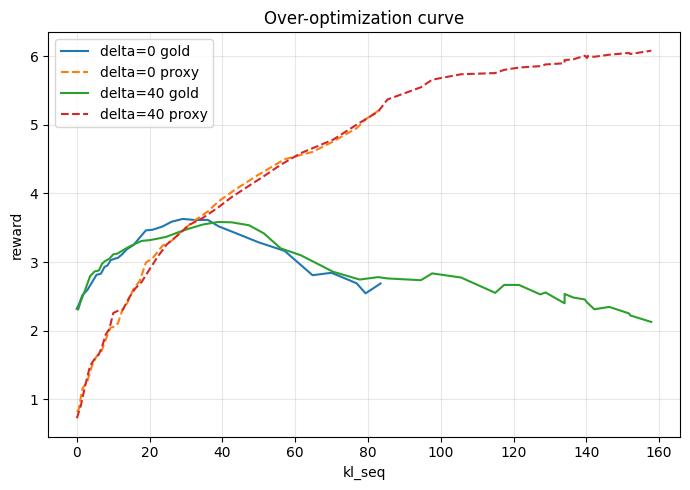

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(grpo_kl, grpo_gold, label='delta=0 gold', linestyle='-')
plt.plot(grpo_kl, grpo_proxy, label='delta=0 proxy', linestyle='--')
plt.plot(drro_kl, drro_gold, label='delta=40 gold', linestyle='-')
plt.plot(drro_kl, drro_proxy, label='delta=40 proxy', linestyle='--')
plt.xlabel(x_key)
plt.ylabel('reward')
plt.title('Over-optimization curve')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
